# Customer Analytics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
customers = pd.read_csv("../data/engineered/customers_engineered.csv")
orders = pd.read_csv("../data/engineered/orders_engineered.csv")

## Customer Overview

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_location
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,"franca, SP"
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,"sao bernardo do campo, SP"
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,"sao paulo, SP"
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,"mogi das cruzes, SP"
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,"campinas, SP"


In [4]:
customers.shape

(99441, 6)

In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
 5   customer_location         99441 non-null  object
dtypes: int64(1), object(5)
memory usage: 4.6+ MB


## Total Customers

In [6]:
total_customers = customers["customer_unique_id"].nunique()

print(f"Total Unique Customers: {total_customers:,}")

Total Unique Customers: 96,096


The dataset contains the complete list of unique customers who placed orders on the Olist platform. This metric serves as the baseline for customer-focused analyses.

## Customer Distribution by State

In [7]:
state_distribution = (
    customers["customer_state"]
    .value_counts()
    .sort_values(ascending=False)
)

state_distribution.head()

SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: customer_state, dtype: int64

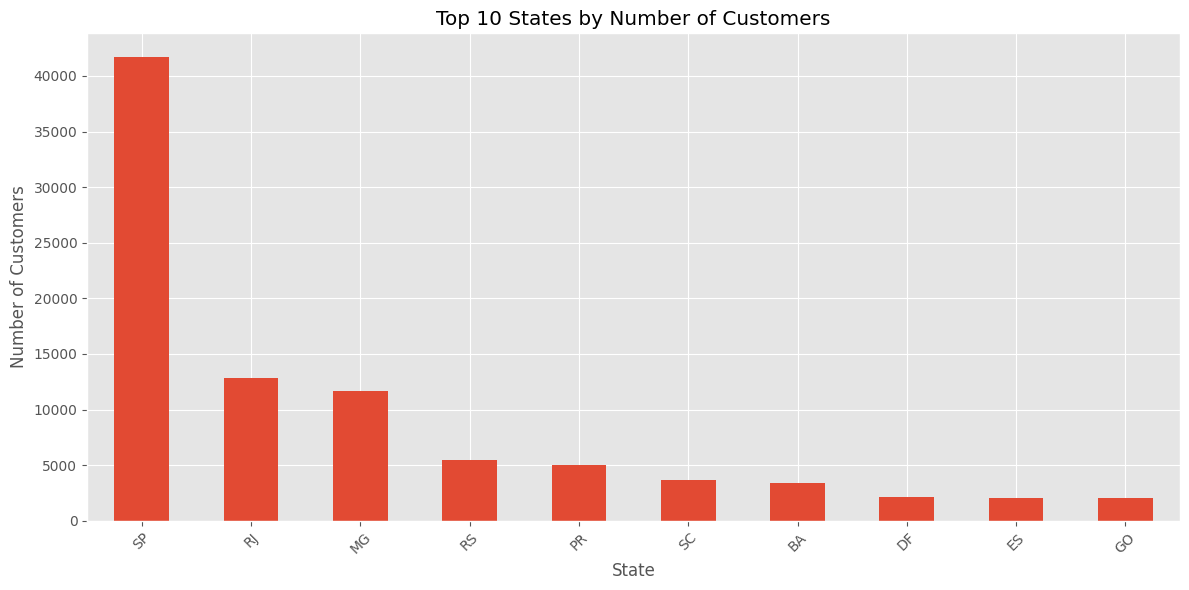

In [8]:
plt.figure(figsize=(12,6))

state_distribution.head(10).plot(kind="bar")

plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The customer base is concentrated in a small number of states. Understanding regional concentration helps identify strong markets and regions with growth opportunities.

## Customer Distribution by City

In [9]:
city_distribution = (
    customers["customer_city"]
    .value_counts()
    .sort_values(ascending=False)
)

city_distribution.head()

sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
Name: customer_city, dtype: int64

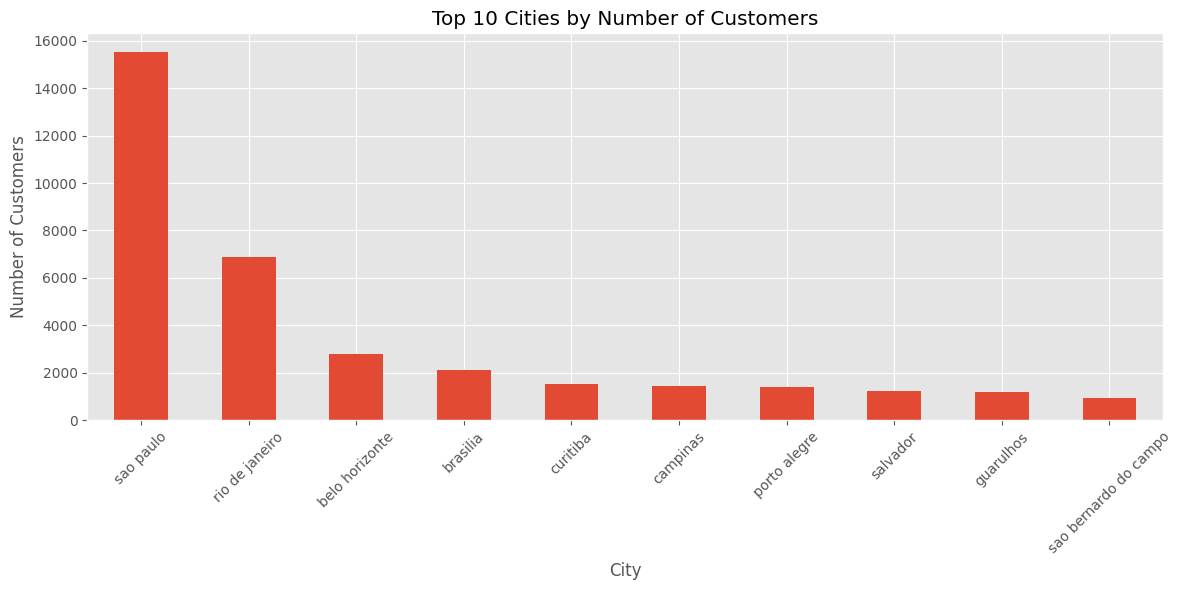

In [10]:
plt.figure(figsize=(12,6))

city_distribution.head(10).plot(kind="bar")

plt.title("Top 10 Cities by Number of Customers")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Customer demand is heavily concentrated in a limited number of cities. These markets represent key areas for customer retention and future business expansion.

## Customer Growth Over Time

In [11]:
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [12]:
customer_orders["order_purchase_timestamp"] = pd.to_datetime(
    customer_orders["order_purchase_timestamp"]
)

customer_orders["purchase_month"] = (
    customer_orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [13]:
monthly_customers = (
    customer_orders
    .groupby("purchase_month")["customer_unique_id"]
    .nunique()
)

monthly_customers.head()

purchase_month
2016-09       4
2016-10     321
2016-12       1
2017-01     765
2017-02    1755
Freq: M, Name: customer_unique_id, dtype: int64

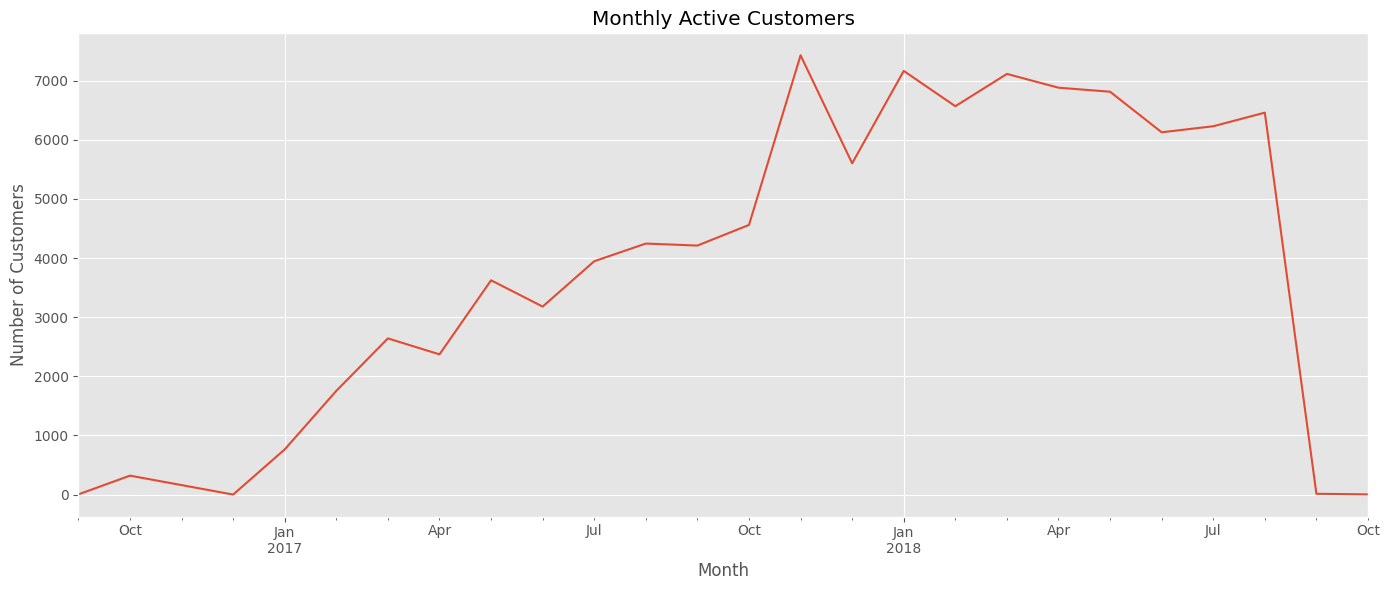

In [14]:
plt.figure(figsize=(14,6))

monthly_customers.plot()

plt.title("Monthly Active Customers")
plt.xlabel("Month")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

Tracking customer growth over time helps identify periods of rapid expansion, seasonal demand, and changes in customer acquisition trends.

## Key Insights

- Customer activity is concentrated in a small number of states and cities.
- Geographic demand is uneven across regions.
- Monthly customer trends reveal changes in customer acquisition over time.

## Business Recommendations

- Increase marketing efforts in states with lower customer penetration.
- Strengthen customer retention programs in high-performing regions.
- Investigate seasonal customer acquisition patterns to optimize promotional campaigns.